---
title: "Infrastructure Investment and Jobs Act Funding Allocation"
subtitle: "DATA 608 Spring 2025 - Story 1"
author: "Stephanie Chiang"
format:
    html:
        cold-fold: true
jupyter: python3
---

In [237]:
import pandas as pd
import numpy as np

# Import the IIJA data
iija_raw = pd.read_excel("story1data.xlsx")

# Import the population data
population_raw = pd.read_excel("https://www2.census.gov/programs-surveys/popest/tables/2020-2024/state/totals/NST-EST2024-POP.xlsx")

# Import the election data
election_raw = pd.read_excel("https://www.fec.gov/documents/4228/federalelections2020.xlsx", sheet_name=8)


In [ ]:
# Check to confirm the imports
print(iija_raw.head(3))
print(population_raw.head(3).iloc[:, 0:3])
print(election_raw.head(3).iloc[:, 0:3])

In [271]:
# Rename the columns in the IIJA data for clarity
iija = iija_raw.copy()
iija.columns = ['state', 'funding_billions']

In [274]:
# Clean up the population data

# select rows 8 to 60 and columns 0 and 6 for the 2024 population data for each state
population = population_raw.iloc[8:60, [0, 6]]

# strip the "." from column 0 and capitalize the strings to match the IIJA data
population.iloc[:, 0] = population.iloc[:, 0].str.strip(".").str.upper()

# rename the columns for merging
population.columns = ['state', 'population']

# join to the iija data frame on the state column
df = iija.merge(population, on="state", how="outer")

print(df.head())

            state  funding_billions  population
0         ALABAMA            3.0000   5157699.0
1          ALASKA            3.7000    740133.0
2  AMERICAN SAMOA            0.0686         NaN
3         ARIZONA            3.5000   7582384.0
4        ARKANSAS            2.8000   3088354.0


In [275]:
# Clean up the election data

# select columns 2, 6, and 11 for the state, candidate, and vote percentage
election = election_raw.iloc[:, [2, 6, 11]]

# rename columns for clarity
election.columns = ['state', 'candidate', 'vote_pct']

# drop rows where candidate is not Biden or Trump
election = election[election.candidate.isin(['Biden', 'Trump'])]

# pivot the data for merging
election = election.pivot_table(index="state", columns="candidate", values="vote_pct").reset_index()

# capitalize the state column
election['state'] = election['state'].str.upper()

# merge the election data with the new data frame
df = df.merge(election, on="state", how="left") 

print(df.head())

            state  funding_billions  population     Biden     Trump
0         ALABAMA            3.0000   5157699.0  0.365700  0.620316
1          ALASKA            3.7000    740133.0  0.427720  0.528331
2  AMERICAN SAMOA            0.0686         NaN       NaN       NaN
3         ARIZONA            3.5000   7582384.0  0.493647  0.490560
4        ARKANSAS            2.8000   3088354.0  0.347751  0.623957


In [276]:
# Fix the Delaware typo - select the value and drop the misspelled row
df.iloc[8, 1] = df.iloc[9, 1]
df.drop([9], inplace=True)

print(df.head(10))

                   state  funding_billions  population     Biden     Trump
0                ALABAMA            3.0000   5157699.0  0.365700  0.620316
1                 ALASKA            3.7000    740133.0  0.427720  0.528331
2         AMERICAN SAMOA            0.0686         NaN       NaN       NaN
3                ARIZONA            3.5000   7582384.0  0.493647  0.490560
4               ARKANSAS            2.8000   3088354.0  0.347751  0.623957
5             CALIFORNIA           18.4000  39431263.0  0.634844  0.343203
6               COLORADO            3.2000   5957493.0  0.553995  0.418979
7            CONNECTICUT            2.5000   3675069.0  0.592607  0.391871
8               DELAWARE            0.7920   1051917.0  0.587430  0.397749
10  DISTRICT OF COLUMBIA            1.1000    702250.0  0.921497  0.053973


In [277]:
# Prepare the data for plotting
df_plt = df.copy()

# calculate the share of funding and population for each state
df_plt['funding_pct'] = df_plt['funding_billions'] / df_plt['funding_billions'].sum()
df_plt['population_pct'] = df_plt['population'] / df_plt['population'].sum()

# calculate the difference in share between funding and population
df_plt['diff_pct'] = df_plt['funding_pct'] - df_plt['population_pct']

# assign a victor for each state based on the higher percentage of votes
df_plt['2020_victor'] = np.where(df_plt['Biden'] > df_plt['Trump'], 'dem', 'rep')

# assign a category for if the diff_pct is positive (state has more funding relative to population)
# or negative (state has less funding relative to population)
df_plt['funding'] = np.where(df_plt['diff_pct'] > 0, 'surplus', 'deficit')

# sort the data frame by the difference in funding and population percentages
df_plt = df_plt.sort_values("diff_pct")

# drop any rows with missing values in the diff_pct column
# This removes the territories, which do not vote in the presidential election anyway.
df_plt = df_plt.dropna(subset=["diff_pct"])

print(df_plt.head(25))

             state  funding_billions  population     Biden     Trump  \
11         FLORIDA            8.2000  23372215.0  0.478615  0.512198   
5       CALIFORNIA           18.4000  39431263.0  0.634844  0.343203   
48           TEXAS           14.2000  31290831.0  0.464790  0.520576   
36  NORTH CAROLINA            4.5000  11046024.0  0.485862  0.499344   
12         GEORGIA            5.0000  11180878.0  0.494731  0.492375   
35        NEW YORK           10.1000  19867248.0  0.304339  0.188700   
23        MARYLAND            2.7000   6263220.0  0.653607  0.321503   
3          ARIZONA            3.5000   7582384.0  0.493647  0.490560   
45  SOUTH CAROLINA            2.3000   5478831.0  0.434301  0.551103   
25        MICHIGAN            5.2000  10140459.0  0.506208  0.478373   
26       MINNESOTA            2.7000   5793151.0  0.523951  0.452849   
56       WISCONSIN            2.8000   5960975.0  0.494495  0.488224   
17         INDIANA            3.4000   6924275.0  0.409631  0.57

The first plot demonstrates the differences between the funding and population percentages for the 10 states with greatest positive differences, or surpluses. Each state is colored by its winner for the 2020 presidential election.

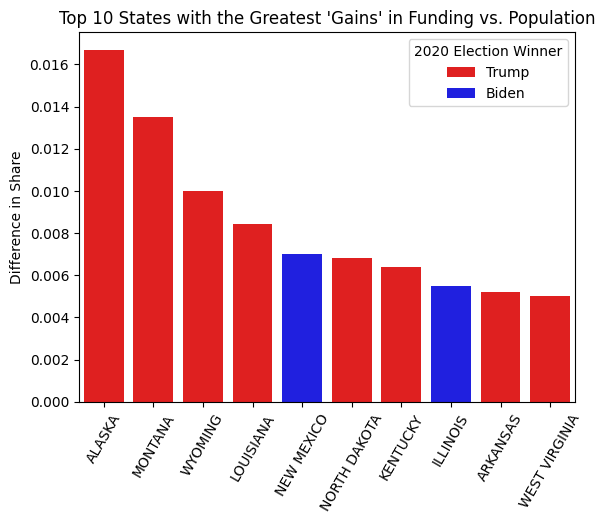

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt

pos = sns.barplot(
    data=df_plt.tail(10),
    x="state",
    y="diff_pct",
    hue="2020_victor",
    palette={"dem": "blue", "rep": "red"},
)

plt.xticks(rotation=60)
plt.ylabel("Difference in Share")
plt.xlabel("")
plt.title("Top 10 States with the Greatest 'Gains' in Funding vs. Population")
legend = pos.legend(title="2020 Election Winner")
legend.texts[0].set_text("Trump")
legend.texts[1].set_text("Biden")
plt.gca().invert_xaxis()

plt.show()

The second plot shows the same gap between funding and population percentages, but for the 10 states with largest negative differences, or deficits, along with how the state voted.

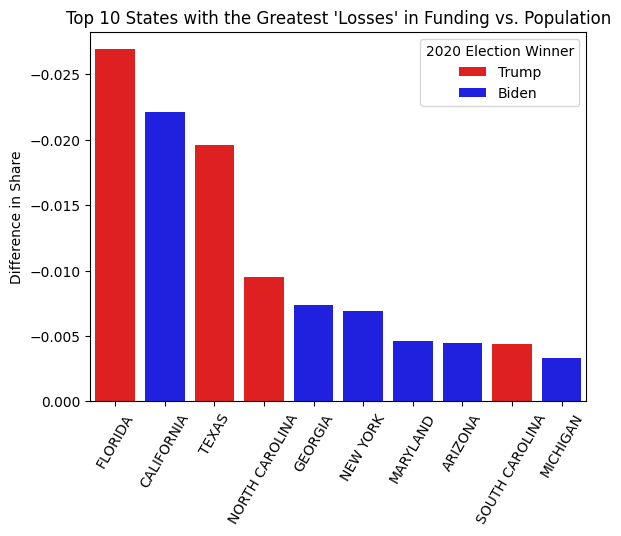

In [279]:
neg = sns.barplot(
    data=df_plt.head(10),
    x="state",
    y="diff_pct",
    hue="2020_victor",
    palette={"dem": "blue", "rep": "red"},
)

plt.xticks(rotation=60)
plt.ylabel("Difference in Share")
plt.xlabel("")
plt.title("Top 10 States with the Greatest 'Losses' in Funding vs. Population")
legend = neg.legend(title="2020 Election Winner")
legend.texts[0].set_text("Trump")
legend.texts[1].set_text("Biden")
plt.gca().invert_yaxis()

plt.show()

### Is the allocation equitable based on the population of each of the States and Territories, or is bias apparent?

There is a noticeable bias in the allocation of funds against states that were won by Joe Biden in the 2020 election. These states tend to have a higher percentage of the overall population and received a lower percentage of the funds.

### Does the allocation favor the political interests of the Biden administration?

This could indicate that the allocation was meant to favor the interests of the Biden administration for a future election (but he did not run). It could also indicate the opposite - that the allocation had a negative effect on states that voted for him in that 2020 election.


For an even simpler comparison, this histogram shows the number of surplus and deficit states and how they voted.

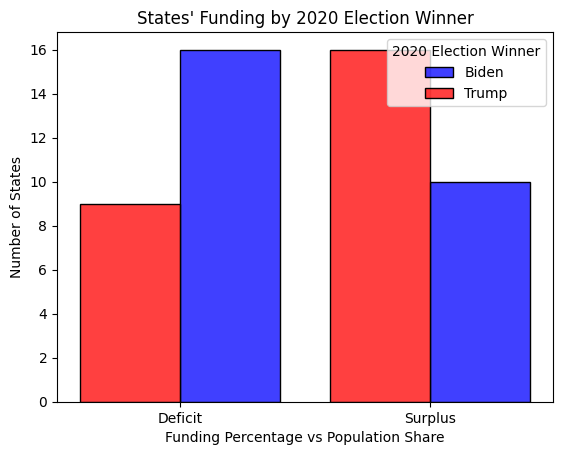

In [280]:
h = sns.histplot(
    data=df_plt,
    x="funding",
    hue="2020_victor",
    multiple="dodge",
    shrink=0.8,
    palette={"dem": "blue", "rep": "red"},
)

plt.xlabel("Funding Percentage vs Population Share")
h.set_xticks([0, 1])
h.set_xticklabels(["Deficit", "Surplus"])
plt.ylabel("Number of States")
plt.title("States' Funding by 2020 Election Winner")
plt.legend(title="2020 Election Winner", labels=["Biden", "Trump"])

plt.show()


### 3 Minute Story

Using data from the IIJA on fund allocation, the US Census Bureau for population estimates and the FEC for election results, I examined whether states received funding in proportion to their population election results, and if the 2020 election results had any effect. Using the Python visualization library Seaborn, I created simple bar plots and a histogram that showed the differences very clearly. In general, states that received less funding compared to their population share tended to vote for Biden in 2020. States that received more funding relative to their size were more likely to have supported his opposition. There could be many complex reasons for this disparity, and also many implications now that we are past the 2024 elections.

### Big Idea

I visualized how states that received less funding relative to their share of the country's population tended to vote for Biden in the previous election.